# Amazon Sales & Customer Analytics

## Mini Project — Python Data Analysis & Visualization

### Objective
Analyze Amazon-style e-commerce sales to understand revenue, profit, customers, products, regions, delivery performance, ratings and order behavior.

### Workflow
1. Load and inspect data
2. Clean missing values and duplicates
3. Feature engineering
4. KPI analysis
5. Product and category analysis
6. Regional analysis
7. Customer-segment analysis
8. Monthly sales and profit trends
9. Delivery and rating analysis
10. Matplotlib visualizations
11. Seaborn visualizations
12. Plotly interactive visualizations
13. Business insights

> **Dataset note:** This project uses a synthetic Amazon-style sales dataset generated for academic analytics practice. It is not an official Amazon internal dataset.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load dataset
df = pd.read_csv("amazon_sales_data.csv", parse_dates=["order_date"])
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
display(df.head())

Rows: 2,500
Columns: 23


,order_id,customer_id,order_date,product_name,category,region,state,city,quantity,unit_price,discount,sales,profit,rating,delivery_days,order_status,payment_method,customer_segment,year,month,month_name,quarter,profit_margin_pct
0,AMZ100000,CUST10007,2025-01-01,USB-C Hub,Electronics,North,Haryana,Gurugram,1,27.44,0.283,19.67,-6.05,4.4,5,Delivered,Debit Card,Corporate,2025,1,Jan,Q1,-30.76
1,AMZ100001,CUST10314,2024-11-13,Novel Collection,Books,South,Tamil Nadu,Coimbatore,2,51.15,0.013,100.97,29.83,4.6,3,Delivered,UPI,Consumer,2024,11,Nov,Q4,29.54
2,AMZ100002,CUST10817,2024-05-23,Coffee Maker,Home,South,Karnataka,Bengaluru,1,111.68,0.151,94.82,19.64,3.9,7,Delivered,Credit Card,Home Office,2024,5,May,Q2,20.71
3,AMZ100003,CUST10103,2025-01-18,Fitness Tracker,Sports,North,Delhi,Delhi,1,59.92,0.175,49.43,11.02,3.9,5,Delivered,Debit Card,Home Office,2025,1,Jan,Q1,22.29
4,AMZ100004,CUST10821,2024-08-03,Smart Watch,Electronics,South,Tamil Nadu,Chennai,1,145.68,0.276,105.47,7.16,3.6,3,Delivered,Debit Card,Corporate,2024,8,Aug,Q3,6.79


In [3]:
# Initial inspection
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

Data types:


,dtype
order_id,object
customer_id,object
order_date,datetime64[ns]
product_name,object
category,object
region,object
state,object
city,object
quantity,int64
unit_price,float64



Missing values:


,missing_values
order_id,0
customer_id,0
order_date,0
product_name,0
category,0
region,0
state,0
city,0
quantity,0
unit_price,0



Duplicate rows: 0


In [4]:
# Data cleaning and feature engineering
data = df.copy()

data = data.drop_duplicates().reset_index(drop=True)

data["rating"] = data["rating"].fillna(data["rating"].median())

data["order_date"] = pd.to_datetime(data["order_date"])
data["year"] = data["order_date"].dt.year
data["month"] = data["order_date"].dt.month
data["month_name"] = data["order_date"].dt.strftime("%b")
data["quarter"] = "Q" + data["order_date"].dt.quarter.astype(str)

data["profit_margin_pct"] = np.where(
    data["sales"] != 0,
    data["profit"] / data["sales"] * 100,
    0
).round(2)

print("Cleaned shape:", data.shape)
print("Remaining missing values:", int(data.isna().sum().sum()))

Cleaned shape: (2500, 23)
Remaining missing values: 0


In [5]:
# Descriptive statistics
display(data.describe().T.round(2))

,count,mean,min,25%,50%,75%,max,std
order_date,2500,2024-12-28 12:26:29.760000,2024-01-01 00:00:00,2024-06-28 00:00:00,2024-12-30 00:00:00,2025-06-29 00:00:00,2025-12-31 00:00:00,NaN
quantity,2500.0,1.29,1.0,1.0,1.0,2.0,3.0,0.521161
unit_price,2500.0,152.386508,14.74,37.7525,65.17,123.4625,969.44,229.188783
discount,2500.0,0.150951,0.0,0.079,0.152,0.224,0.3,0.085598
sales,2500.0,138.879684,0.0,23.135,52.825,115.2825,2540.79,253.089371
profit,2500.0,13.574284,-58.75,0.0,5.9,15.705,315.16,28.094341
rating,2500.0,4.03396,2.2,3.7,4.0,4.4,5.0,0.526461
delivery_days,2500.0,4.0636,1.0,3.0,4.0,5.0,11.0,1.732731
year,2500.0,2024.498,2024.0,2024.0,2024.0,2025.0,2025.0,0.500096
month,2500.0,6.4516,1.0,4.0,6.0,9.0,12.0,3.41519


In [6]:
# KPI summary
kpis = pd.DataFrame({
    "Metric": [
        "Total Sales", "Total Profit", "Total Orders", "Total Quantity",
        "Unique Customers", "Unique Products", "Average Order Value",
        "Average Rating", "Average Delivery Days"
    ],
    "Value": [
        data["sales"].sum(),
        data["profit"].sum(),
        data["order_id"].nunique(),
        data["quantity"].sum(),
        data["customer_id"].nunique(),
        data["product_name"].nunique(),
        data["sales"].sum() / data["order_id"].nunique(),
        data["rating"].mean(),
        data["delivery_days"].mean()
    ]
})
display(kpis.round(2))

,Metric,Value
0,Total Sales,347199.21
1,Total Profit,33935.71
2,Total Orders,2500.00
3,Total Quantity,3225.00
4,Unique Customers,881.00
5,Unique Products,25.00
6,Average Order Value,138.88
7,Average Rating,4.03
8,Average Delivery Days,4.06


In [7]:
# Product analysis
product_summary = (
    data.groupby("product_name")
    .agg(
        sales=("sales","sum"),
        profit=("profit","sum"),
        orders=("order_id","nunique"),
        quantity=("quantity","sum"),
        avg_rating=("rating","mean")
    )
    .sort_values("sales", ascending=False)
)
display(product_summary.head(15).round(2))

,sales,profit,orders,quantity,avg_rating
product_name,,,,,
Laptop Pro 14,88843.99,7911.43,113,131,4.10
Smartphone X,73241.71,5807.27,110,147,4.06
4K Smart TV,48914.47,3490.75,99,124,4.02
Office Chair,15791.38,1839.66,93,126,4.09
Coffee Maker,13791.25,1706.04,114,157,4.01
Smart Watch,13620.99,1163.17,108,135,4.04
Cookware Set,10489.79,1405.33,99,114,3.96
Mechanical Keyboard,9452.26,800.13,113,138,4.08
Air Fryer,7556.84,806.57,79,102,3.95


In [8]:
# Category analysis
category_summary = (
    data.groupby("category")
    .agg(
        sales=("sales","sum"),
        profit=("profit","sum"),
        orders=("order_id","nunique"),
        quantity=("quantity","sum"),
        avg_rating=("rating","mean")
    )
    .sort_values("sales", ascending=False)
)
display(category_summary.round(2))

,sales,profit,orders,quantity,avg_rating
category,,,,,
Electronics,254165.94,20737.20,943,1198,4.05
Home,51542.74,6156.37,500,640,4.00
Fashion,13016.24,2205.11,300,404,4.02
Books,12548.63,2496.57,288,386,4.04
Sports,12454.69,1752.15,270,346,4.03
Office,3470.97,588.31,199,251,4.05


In [9]:
# Regional analysis
region_summary = (
    data.groupby(["region","state"])
    .agg(
        sales=("sales","sum"),
        profit=("profit","sum"),
        orders=("order_id","nunique")
    )
    .sort_values("sales", ascending=False)
)
display(region_summary.head(15).round(2))

sales   profit  orders
region state                                 
West   Maharashtra  56230.68  5745.17     437
South  Tamil Nadu   54284.83  5695.83     433
       Telangana    41398.55  3753.29     218
North  Delhi        31021.30  2546.30     217
East   West Bengal  30568.63  2827.13     207
North  Rajasthan    27937.41  2879.71     189
West   Gujarat      27196.07  2831.23     213
South  Kerala       26822.78  2036.37     194
North  Haryana      26808.58  2964.73     194
South  Karnataka    24930.38  2655.95     198

In [10]:
# Customer segment analysis
segment_summary = (
    data.groupby("customer_segment")
    .agg(
        sales=("sales","sum"),
        profit=("profit","sum"),
        orders=("order_id","nunique"),
        avg_order_value=("sales","mean")
    )
    .sort_values("sales", ascending=False)
)
display(segment_summary.round(2))

,sales,profit,orders,avg_order_value
customer_segment,,,,
Corporate,119933.29,11821.07,847,141.60
Consumer,114904.49,10830.85,811,141.68
Home Office,112361.43,11283.79,842,133.45


In [11]:
# Monthly analysis
monthly = (
    data.groupby(data["order_date"].dt.to_period("M"))
    .agg(
        sales=("sales","sum"),
        profit=("profit","sum"),
        orders=("order_id","nunique")
    )
    .reset_index()
)
monthly["order_date"] = monthly["order_date"].dt.to_timestamp()
display(monthly.tail(12).round(2))

,order_date,sales,profit,orders
12,2025-01-01,14740.88,1607.25,119
13,2025-02-01,10311.53,987.31,84
14,2025-03-01,13831.45,1084.56,106
15,2025-04-01,15448.96,1419.61,101
16,2025-05-01,13548.30,1368.30,95
17,2025-06-01,15218.17,1524.15,127
18,2025-07-01,12233.12,1270.03,100
19,2025-08-01,14212.51,1473.55,105
20,2025-09-01,19684.71,1820.12,100
21,2025-10-01,12097.28,1327.54,90


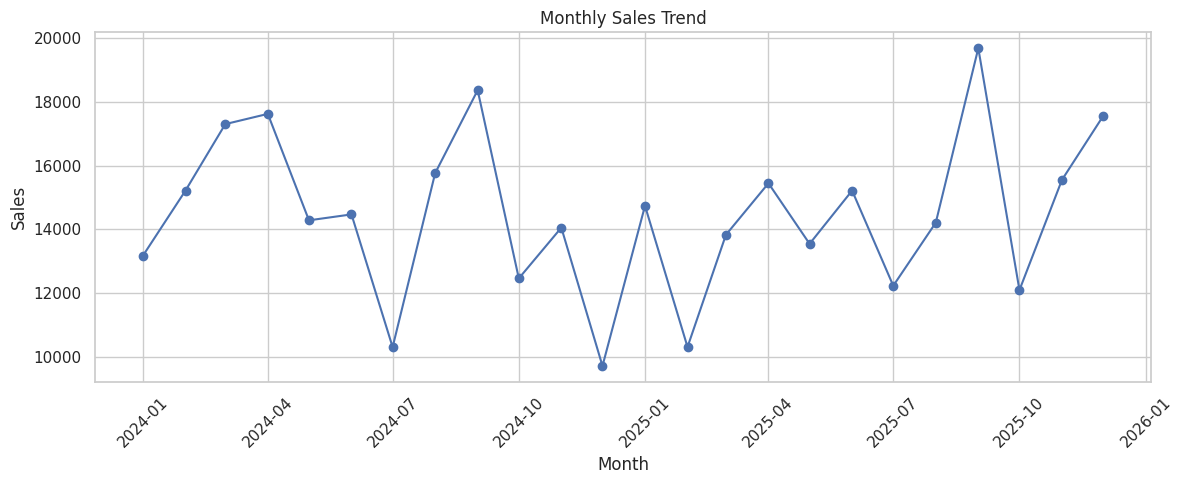

In [12]:
# Chart 1 — Monthly sales trend
plt.figure(figsize=(12,5))
plt.plot(monthly["order_date"], monthly["sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

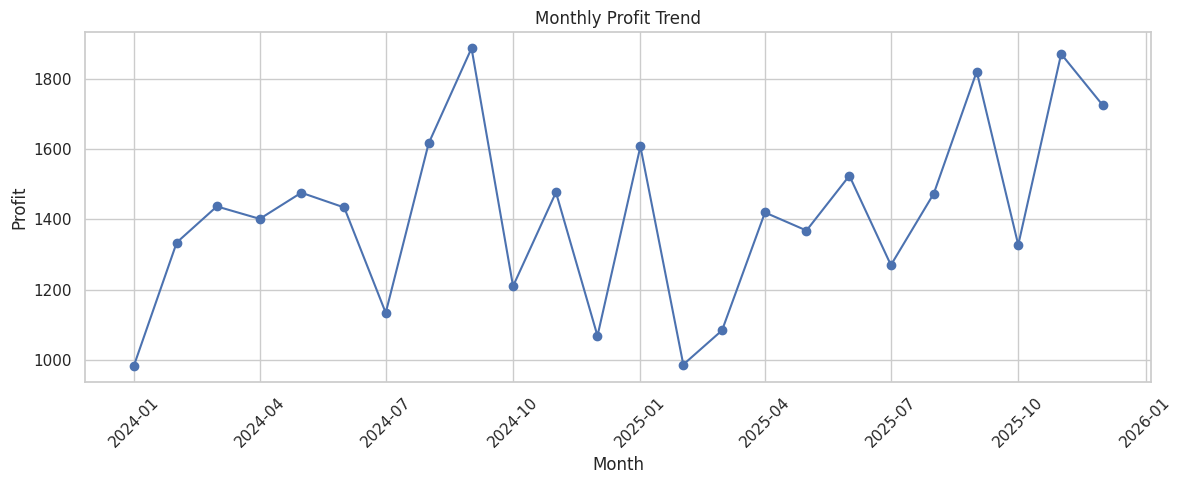

In [13]:
# Chart 2 — Monthly profit trend
plt.figure(figsize=(12,5))
plt.plot(monthly["order_date"], monthly["profit"], marker="o")
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

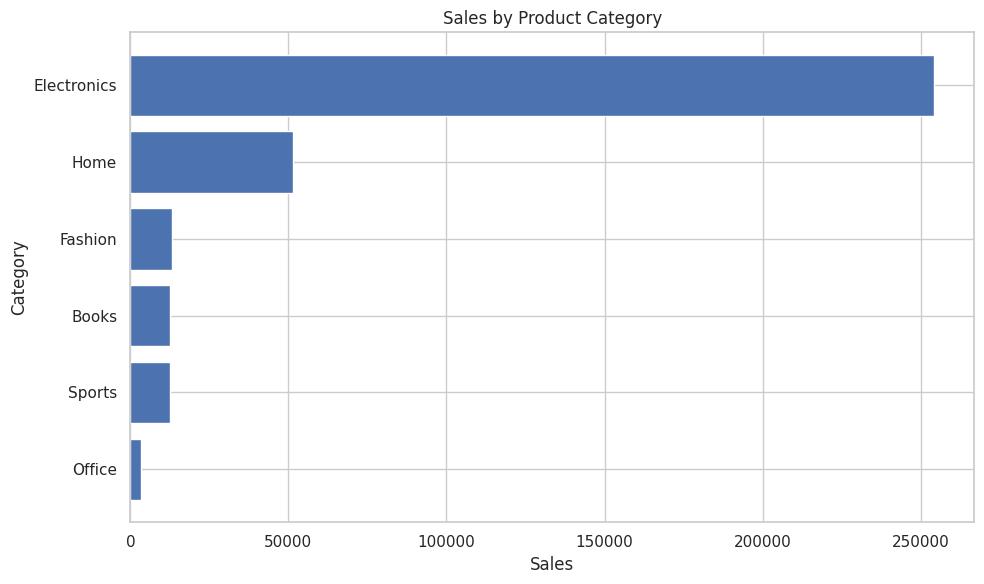

In [14]:
# Chart 3 — Sales by category
p = category_summary.sort_values("sales")
plt.figure(figsize=(10,6))
plt.barh(p.index, p["sales"])
plt.title("Sales by Product Category")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

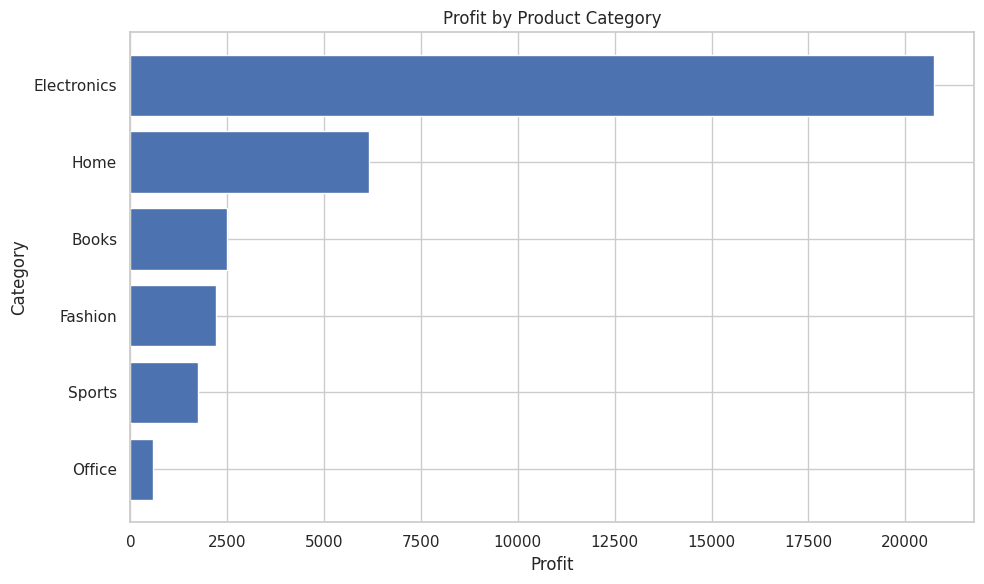

In [15]:
# Chart 4 — Profit by category
p = category_summary.sort_values("profit")
plt.figure(figsize=(10,6))
plt.barh(p.index, p["profit"])
plt.title("Profit by Product Category")
plt.xlabel("Profit")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

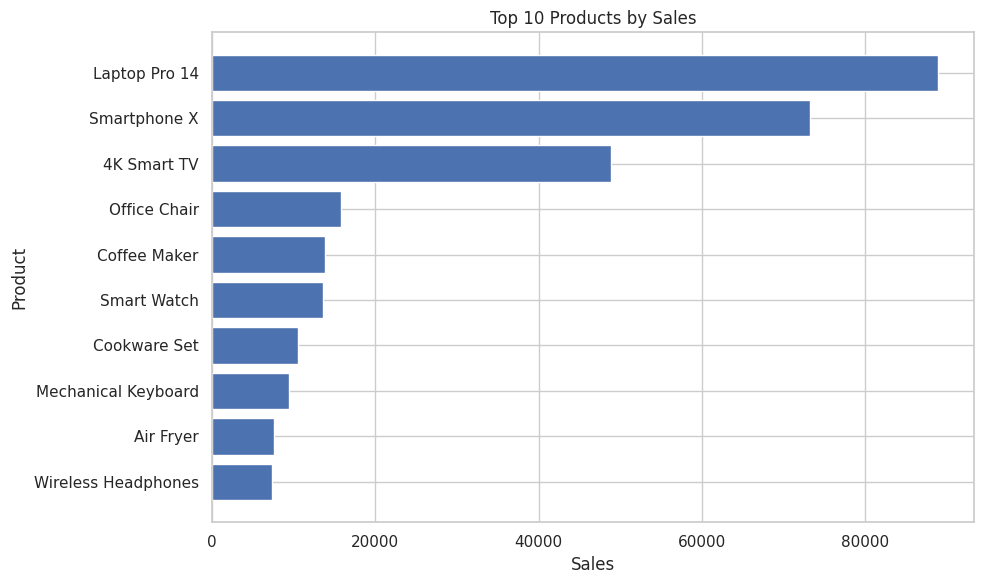

In [16]:
# Chart 5 — Top products by sales
p = product_summary.head(10).sort_values("sales")
plt.figure(figsize=(10,6))
plt.barh(p.index, p["sales"])
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

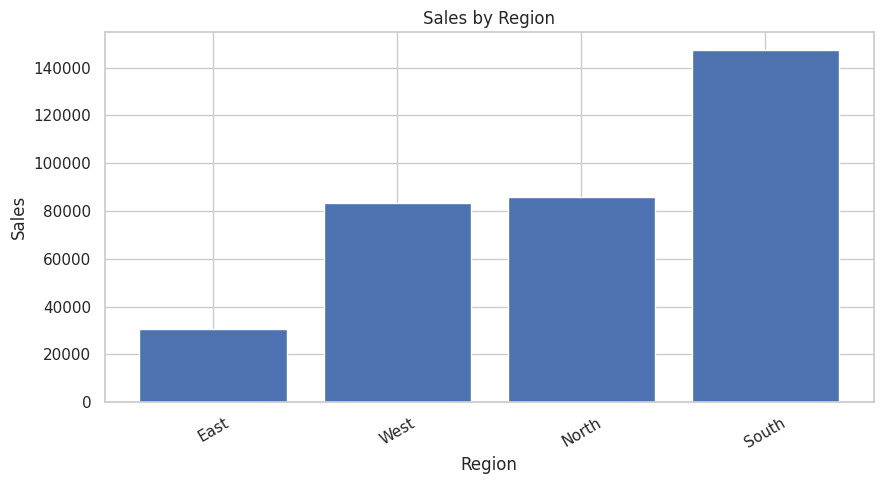

In [17]:
# Chart 6 — Regional sales
region_plot = data.groupby("region")["sales"].sum().sort_values()
plt.figure(figsize=(9,5))
plt.bar(region_plot.index, region_plot.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

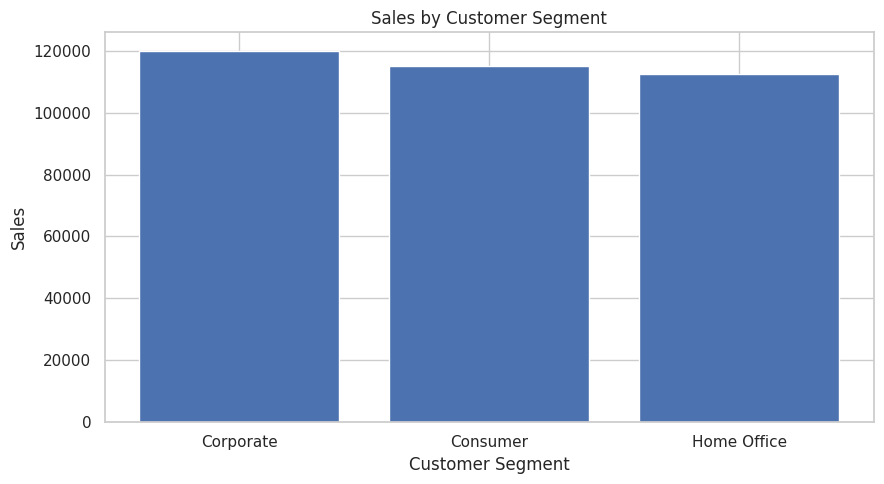

In [18]:
# Chart 7 — Customer segment sales
plt.figure(figsize=(9,5))
plt.bar(segment_summary.index, segment_summary["sales"])
plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

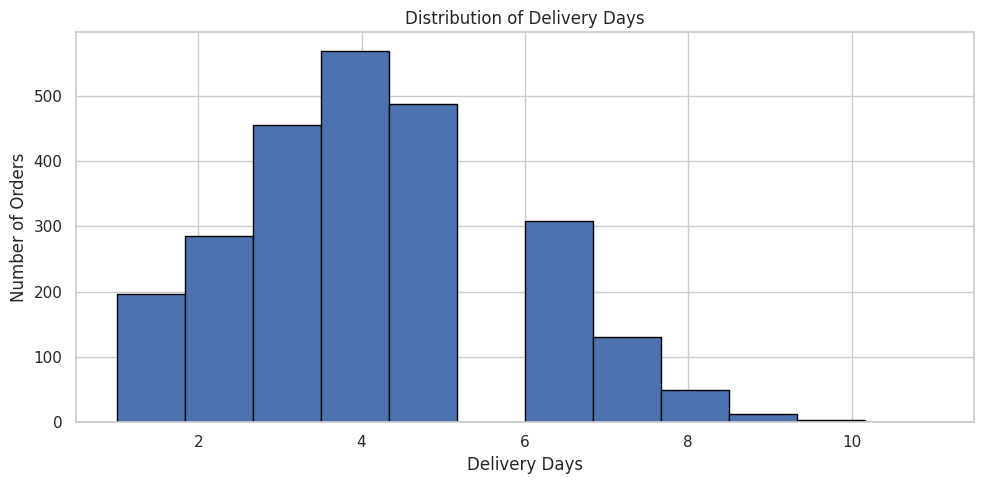

In [19]:
# Chart 8 — Delivery time distribution
plt.figure(figsize=(10,5))
plt.hist(data["delivery_days"], bins=12, edgecolor="black")
plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

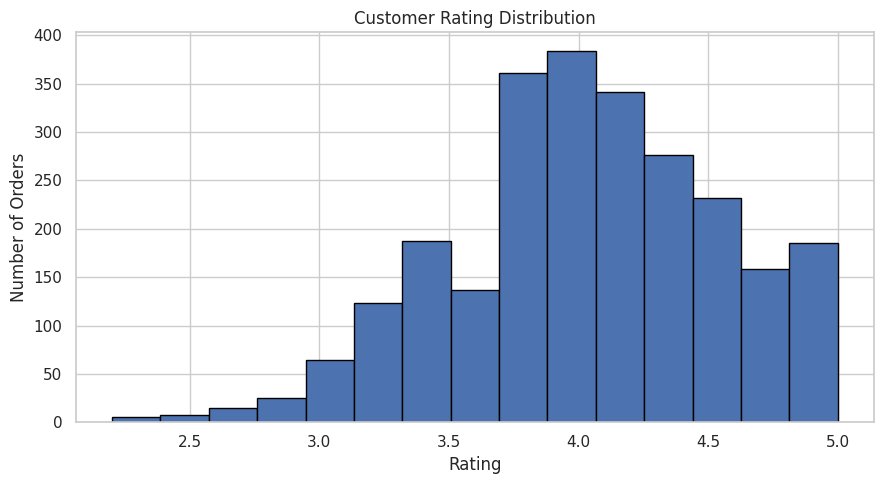

In [20]:
# Chart 9 — Rating distribution
plt.figure(figsize=(9,5))
plt.hist(data["rating"], bins=15, edgecolor="black")
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

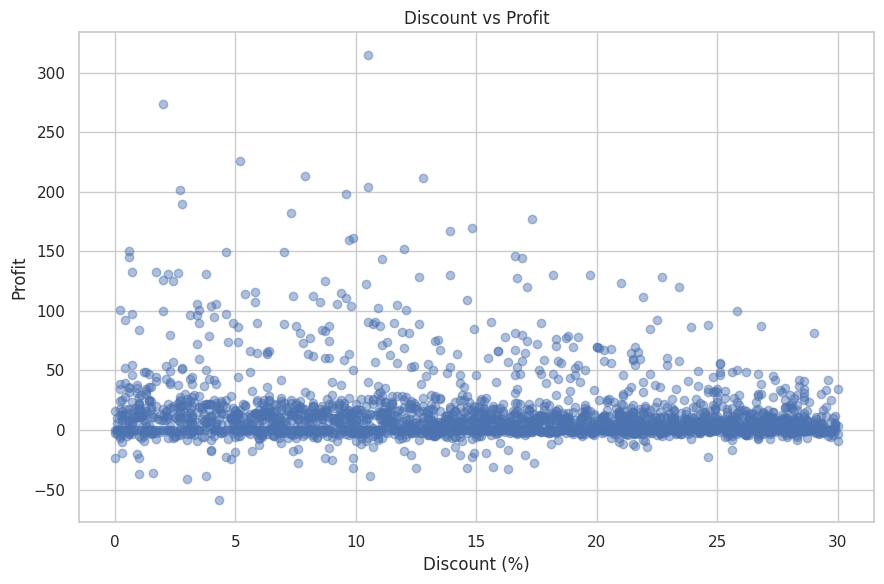

In [21]:
# Chart 10 — Discount vs profit
plt.figure(figsize=(9,6))
plt.scatter(data["discount"] * 100, data["profit"], alpha=.45)
plt.title("Discount vs Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

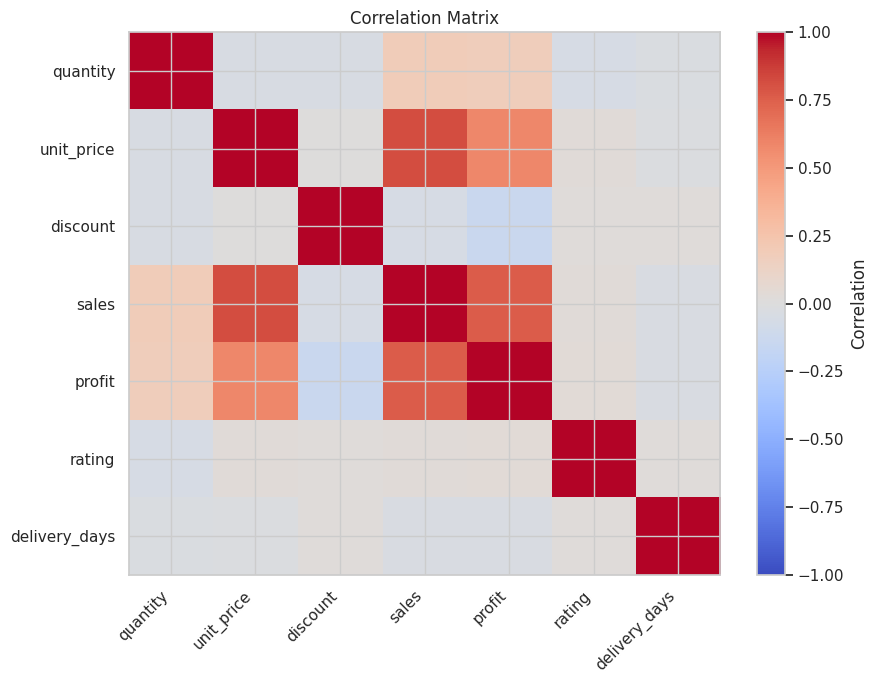

In [22]:
# Correlation analysis
corr_cols = [
    "quantity","unit_price","discount","sales","profit",
    "rating","delivery_days","popularity" if "popularity" in data.columns else "quantity"
]
corr_cols = list(dict.fromkeys([c for c in corr_cols if c in data.columns]))
corr = data[corr_cols].corr()

plt.figure(figsize=(9,7))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [23]:
# Interactive Plotly 1 — Sales by category
fig = px.bar(
    category_summary.reset_index(),
    x="category",
    y="sales",
    color="profit",
    hover_data=["orders","quantity","avg_rating"],
    title="Interactive: Sales by Category"
)
fig.show()

In [24]:
# Interactive Plotly 2 — Monthly sales
fig = px.line(
    monthly,
    x="order_date",
    y="sales",
    markers=True,
    title="Interactive: Monthly Sales Trend"
)
fig.show()

In [25]:
# Interactive Plotly 3 — Sales vs profit
fig = px.scatter(
    data.sample(min(1000, len(data)), random_state=42),
    x="sales",
    y="profit",
    size="quantity",
    color="category",
    hover_name="product_name",
    hover_data=["region","city","customer_segment","rating","discount"],
    title="Interactive: Sales vs Profit"
)
fig.show()

In [26]:
# Order status analysis
status_summary = data.groupby("order_status").agg(
    orders=("order_id","nunique"),
    sales=("sales","sum"),
    profit=("profit","sum")
).sort_values("orders", ascending=False)
display(status_summary.round(2))

,orders,sales,profit
order_status,,,
Delivered,1661,277298.77,36249.00
Returned,439,69900.44,-2313.29
Cancelled,400,0.00,0.00


In [27]:
# Payment method analysis
payment_summary = data.groupby("payment_method").agg(
    orders=("order_id","nunique"),
    sales=("sales","sum"),
    avg_order_value=("sales","mean")
).sort_values("sales", ascending=False)
display(payment_summary.round(2))

,orders,sales,avg_order_value
payment_method,,,
UPI,497,79531.57,160.02
Amazon Pay,511,71082.09,139.10
Debit Card,521,66989.27,128.58
Credit Card,491,66958.52,136.37
Net Banking,480,62637.76,130.50


In [28]:
# Top customers by sales
customer_summary = (
    data.groupby("customer_id")
    .agg(
        sales=("sales","sum"),
        orders=("order_id","nunique"),
        quantity=("quantity","sum")
    )
    .sort_values("sales", ascending=False)
)
display(customer_summary.head(15).round(2))

,sales,orders,quantity
customer_id,,,
CUST10044,3263.28,4,6
CUST10493,2959.48,3,5
CUST10726,2503.68,7,11
CUST10721,2427.69,5,6
CUST10693,2300.37,4,6
CUST10434,2254.17,4,6
CUST10903,2162.59,3,4
CUST10237,2154.71,8,14
CUST10182,2126.55,4,5


In [29]:
# Automated business insights
top_category = category_summary.index[0]
top_product = product_summary.index[0]
top_region = data.groupby("region")["sales"].sum().idxmax()
top_segment = segment_summary.index[0]
best_month = monthly.loc[monthly["sales"].idxmax(), "order_date"].strftime("%B %Y")

insights = [
    "## Key Business Insights",
    f"- **Highest-sales category:** {top_category}.",
    f"- **Top product by sales:** {top_product}.",
    f"- **Highest-sales region:** {top_region}.",
    f"- **Largest customer segment by sales:** {top_segment}.",
    f"- **Highest-sales month:** {best_month}.",
    f"- **Average order value:** {data['sales'].sum()/data['order_id'].nunique():.2f}.",
    f"- **Average delivery time:** {data['delivery_days'].mean():.2f} days.",
    f"- **Average customer rating:** {data['rating'].mean():.2f}/5.",
    f"- **Overall profit margin:** {(data['profit'].sum()/data['sales'].sum()*100):.2f}%.",
]
display(Markdown("\n".join(insights)))

## Key Business Insights
- **Highest-sales category:** Electronics.
- **Top product by sales:** Laptop Pro 14.
- **Highest-sales region:** South.
- **Largest customer segment by sales:** Corporate.
- **Highest-sales month:** September 2025.
- **Average order value:** 138.88.
- **Average delivery time:** 4.06 days.
- **Average customer rating:** 4.03/5.
- **Overall profit margin:** 9.77%.

In [30]:
# Final project summary
print("AMAZON SALES & CUSTOMER ANALYTICS — COMPLETED")
print("=" * 60)
print(f"Orders analyzed       : {data['order_id'].nunique():,}")
print(f"Customers analyzed    : {data['customer_id'].nunique():,}")
print(f"Products analyzed     : {data['product_name'].nunique()}")
print(f"Total sales           : {data['sales'].sum():,.2f}")
print(f"Total profit          : {data['profit'].sum():,.2f}")
print(f"Average order value   : {data['sales'].sum()/data['order_id'].nunique():,.2f}")
print(f"Average rating        : {data['rating'].mean():.2f}/5")
print(f"Average delivery days : {data['delivery_days'].mean():.2f}")
print("=" * 60)
print("All Python analysis cells executed successfully.")

AMAZON SALES & CUSTOMER ANALYTICS — COMPLETED
Orders analyzed       : 2,500
Customers analyzed    : 881
Products analyzed     : 25
Total sales           : 347,199.21
Total profit          : 33,935.71
Average order value   : 138.88
Average rating        : 4.03/5
Average delivery days : 4.06
All Python analysis cells executed successfully.
